# Lab 07 — NLP Evaluation: Airline Tweet Sentiment Classification

**Objective.** Compare a majority baseline with validation-tuned Multinomial Naive Bayes under a leakage-safe three-class protocol.

**Data.** `all_datasets/lab07-Tweets.csv`.

**Run.** From the course folder, run `cd all_experiments`, start Jupyter, open this notebook, and choose **Restart Kernel and Run All Cells**.

**Evidence.** The split, validation search, test predictions and metrics, confusion matrix, subgroup scores, and error analysis in `results/lab07/`.

**Workflow**

1. Inspect, normalise and deduplicate the data.
2. Create a fixed stratified split.
3. Fit text features on training data only.
4. Establish a majority-class baseline.
5. Tune Naive Bayes on validation data.
6. Evaluate once on the test data.
7. Inspect subgroup performance and review errors.


## Setup

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix, f1_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

ROOT = Path.cwd().parent
DATA = ROOT / "all_datasets"
RESULTS = ROOT / "results" / "lab07"
RESULTS.mkdir(parents=True, exist_ok=True)
CLASSES = ["negative", "neutral", "positive"]

## Question 1 — Inspect and clean the data

Keep tweet id, text, sentiment and airline. Report the class balance and the number of
duplicate texts. Replace URLs and @mentions with placeholder tokens, then drop duplicates
*before* splitting — both exact copies and tweets that become identical after
normalisation — so that no near-copy can land in two different subsets.

In [2]:
tweets = pd.read_csv(DATA / "lab07-Tweets.csv", dtype={"tweet_id": str})[["tweet_id", "text", "airline_sentiment", "airline"]]


def clean(text):
    text = re.sub(r"https?://\S+|www\.\S+", " URL ", text)
    text = re.sub(r"@\w+", " USER ", text)
    return " ".join(text.lower().split())


print("Raw tweets:", len(tweets), "| exact duplicate texts:", int(tweets.text.duplicated().sum()))
tweets["model_text"] = tweets.text.map(clean)
print("Duplicates after normalisation:", int(tweets.model_text.duplicated().sum()))
tweets = tweets.drop_duplicates("model_text").reset_index(drop=True)
print("Tweets kept:", len(tweets))
display(tweets.airline_sentiment.value_counts(normalize=True).rename("share").round(3).to_frame())

Raw tweets: 14640 | exact duplicate texts: 213
Duplicates after normalisation: 355
Tweets kept: 14285


,share
airline_sentiment,
negative,0.635
neutral,0.209
positive,0.156


**Result and interpretation.** 14,640 tweets shrink to 14,285 after duplicate handling. Negative tweets are
63 % of the data, so a classifier that always says *negative* would score 63 % accuracy
while being useless — macro F1 is the headline metric. Removing near-duplicates before the
split matters: a retweet in the training set and its twin in the test set would inflate
every score.

## Question 2 — Create a fixed stratified split

Split 70/15/15 with seed 42, stratified by sentiment, and save tweet ids with their split
label to `split.csv`.

In [3]:
train, rest = train_test_split(tweets.index, test_size=0.30, random_state=42, stratify=tweets.airline_sentiment)
val, test = train_test_split(rest, test_size=0.50, random_state=42, stratify=tweets.airline_sentiment[rest])

tweets["split"] = "train"
tweets.loc[val, "split"] = "validation"
tweets.loc[test, "split"] = "test"
tweets[["tweet_id", "airline_sentiment", "split"]].to_csv(RESULTS / "split.csv", index=False)
display(pd.crosstab(tweets.split, tweets.airline_sentiment, margins=True))

airline_sentiment,negative,neutral,positive,All
split,,,,
test,1361,447,335,2143
train,6348,2087,1564,9999
validation,1360,447,336,2143
All,9069,2981,2235,14285


**Result and interpretation.** Stratification keeps the 63/21/16 class mix in all three subsets (9,999
training, 2,143 validation and 2,143 test tweets). The test subset is now frozen: nothing
below looks at it until Question 6.

## Question 3 — Fit text features on training data only

Build a bag-of-words with `CountVectorizer` (English stop words removed, terms in fewer
than two training tweets dropped, at most 20,000 features). Fit it on the training texts
only and report the vocabulary size for unigrams and for unigrams plus bigrams.

In [4]:
def vectorizer(ngram_range):
    return CountVectorizer(stop_words="english", min_df=2, max_features=20_000, ngram_range=ngram_range)


for ngram_range in [(1, 1), (1, 2)]:
    vocabulary = vectorizer(ngram_range).fit(tweets.model_text[train]).vocabulary_
    print(f"ngram_range={ngram_range}: {len(vocabulary):,} features")

ngram_range=(1, 1): 4,671 features
ngram_range=(1, 2): 11,850 features


**Result and interpretation.** The vocabulary is learned from training tweets alone, so a word that appears
only in validation or test tweets is unknown to the model — exactly the situation a
deployed classifier faces. Adding bigrams more than doubles the vocabulary and lets the
model see phrases such as *never again* that a unigram model splits apart.

## Question 4 — Establish a majority-class baseline

Predict the most frequent training class for every validation tweet and record its
accuracy and macro F1. Any real model must beat this.

In [5]:
majority = tweets.airline_sentiment[train].mode()[0]
y_val = tweets.airline_sentiment[val]
majority_f1 = f1_score(y_val, [majority] * len(val), average="macro")
print(f"Majority class: {majority} | validation accuracy {(y_val == majority).mean():.3f} | validation macro F1 {majority_f1:.3f}")

Majority class: negative | validation accuracy 0.635 | validation macro F1 0.259


**Result and interpretation.** The majority baseline reaches 63 % accuracy but only 0.26 macro F1, because
its recall on *neutral* and *positive* is zero. This is the number that shows why accuracy
alone is misleading on imbalanced classes.

## Question 5 — Tune Naive Bayes on validation data

Grid-search the n-gram range {(1,1), (1,2)} and the smoothing parameter α ∈ {0.3, 0.5, 1,
2}, scoring by validation macro F1. Save `validation_results.csv` and select the best
setting without looking at the test data.

In [6]:
rows = [{"ngram_range": "majority baseline", "alpha": np.nan, "validation_macro_f1": majority_f1}]
for ngram_range in [(1, 1), (1, 2)]:
    features = vectorizer(ngram_range).fit(tweets.model_text[train])
    X_train, X_val = features.transform(tweets.model_text[train]), features.transform(tweets.model_text[val])
    for alpha in [0.3, 0.5, 1.0, 2.0]:
        model = MultinomialNB(alpha=alpha).fit(X_train, tweets.airline_sentiment[train])
        rows.append({"ngram_range": str(ngram_range), "alpha": alpha,
                     "validation_macro_f1": f1_score(y_val, model.predict(X_val), average="macro")})

validation = pd.DataFrame(rows).sort_values("validation_macro_f1", ascending=False)
validation.to_csv(RESULTS / "validation_results.csv", index=False)
display(validation.round(4))

best = validation.iloc[0]
best_ngram = (1, 2) if best.ngram_range == "(1, 2)" else (1, 1)
print("Selected:", best.ngram_range, "alpha =", best.alpha)

,ngram_range,alpha,validation_macro_f1
5,"(1, 2)",0.3,0.6973
6,"(1, 2)",0.5,0.6903
7,"(1, 2)",1.0,0.6868
1,"(1, 1)",0.3,0.6760
2,"(1, 1)",0.5,0.6739
3,"(1, 1)",1.0,0.6712
8,"(1, 2)",2.0,0.6516
4,"(1, 1)",2.0,0.6442
0,majority baseline,NaN,0.2588


Selected: (1, 2) alpha = 0.3


**Result and interpretation.** Unigrams plus bigrams with light smoothing (α = 0.3) gives the best validation
macro F1, about 0.70. The differences between settings are small, which is itself useful:
Naive Bayes is not very sensitive to α here, and the choice of n-grams matters more than
the smoothing.

## Question 6 — Evaluate once on the test data

Refit the vectoriser and the selected model on the training tweets, predict the test tweets
once, and report accuracy, macro precision, macro recall and macro F1 for the baseline and
the model. Save `metrics.csv`, `test_predictions.csv` and the confusion matrix.

,model,accuracy,macro_precision,macro_recall,macro_f1
0,Majority baseline,0.6351,0.2117,0.3333,0.2589
1,Multinomial NB,0.7699,0.7036,0.6933,0.6978


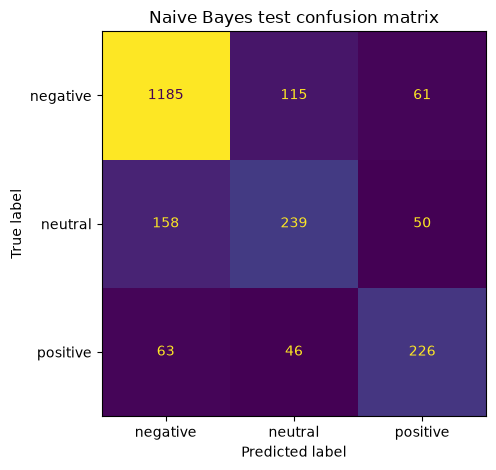

In [7]:
features = vectorizer(best_ngram).fit(tweets.model_text[train])
model = MultinomialNB(alpha=best.alpha).fit(features.transform(tweets.model_text[train]), tweets.airline_sentiment[train])

X_test = features.transform(tweets.model_text[test])
test_set = tweets.loc[test].assign(prediction=model.predict(X_test), confidence=model.predict_proba(X_test).max(axis=1))
test_set.to_csv(RESULTS / "test_predictions.csv", index=False)
y_test = test_set.airline_sentiment


def metric_row(name, prediction):
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, prediction, average="macro", zero_division=0)
    return {"model": name, "accuracy": accuracy_score(y_test, prediction), "macro_precision": precision, "macro_recall": recall, "macro_f1": f1}


metrics = pd.DataFrame([metric_row("Majority baseline", [majority] * len(test)), metric_row("Multinomial NB", test_set.prediction)])
metrics.to_csv(RESULTS / "metrics.csv", index=False)
display(metrics.round(4))

matrix = confusion_matrix(y_test, test_set.prediction, labels=CLASSES)
pd.DataFrame(matrix, index=CLASSES, columns=CLASSES).to_csv(RESULTS / "confusion_matrix.csv")
ConfusionMatrixDisplay(matrix, display_labels=CLASSES).plot(colorbar=False)
plt.title("Naive Bayes test confusion matrix")
plt.tight_layout()
plt.savefig(RESULTS / "confusion_matrix.png", dpi=160)

**Result and interpretation.** On the untouched test set Naive Bayes reaches about 77 % accuracy and 0.70
macro F1 against 63 % and 0.26 for the baseline. The confusion matrix shows the typical
pattern: negative tweets are recognised well, while *neutral* tweets are pulled towards
*negative*, because complaint vocabulary dominates the corpus.

## Question 7 — Inspect subgroup performance and review errors

Report per-class precision, recall and F1, then macro F1 per airline (`per_airline_f1.csv`).
Finally take the four most confident mistakes for each true class — twelve deterministic
errors — tag each with a simple category, and save `error_analysis.csv`.

In [8]:
precision, recall, f1, support = precision_recall_fscore_support(y_test, test_set.prediction, labels=CLASSES)
per_class = pd.DataFrame({"precision": precision, "recall": recall, "f1": f1, "support": support}, index=CLASSES)
per_class.to_csv(RESULTS / "per_class_metrics.csv")
display(per_class.round(3))

rows = []
for airline, group in test_set.groupby("airline"):
    rows.append({"airline": airline, "n_test": len(group), "accuracy": accuracy_score(group.airline_sentiment, group.prediction),
                 "macro_f1": f1_score(group.airline_sentiment, group.prediction, average="macro")})
per_airline = pd.DataFrame(rows).set_index("airline").sort_values("macro_f1")
per_airline.to_csv(RESULTS / "per_airline_f1.csv")
display(per_airline.round(3))


def category(text):
    text = text.lower()
    if "?" in text:
        return "question or request"
    if re.search(r"\b(no|not|never|can't|don't|didn't|won't)\b", text):
        return "negation"
    if len(text.split()) <= 7:
        return "very short text"
    return "mixed or ambiguous wording"


mistakes = test_set[test_set.prediction != test_set.airline_sentiment]
errors = pd.concat(mistakes[mistakes.airline_sentiment == c].nlargest(4, "confidence") for c in CLASSES)
errors = errors.assign(category=errors.text.map(category))
errors[["tweet_id", "airline", "airline_sentiment", "prediction", "confidence", "text", "category"]].to_csv(RESULTS / "error_analysis.csv", index=False)
display(errors[["airline_sentiment", "prediction", "confidence", "text", "category"]])
print("Saved:", sorted(p.name for p in RESULTS.iterdir()))

,precision,recall,f1,support
negative,0.843,0.871,0.857,1361
neutral,0.598,0.535,0.564,447
positive,0.671,0.675,0.673,335


,n_test,accuracy,macro_f1
airline,,,
Delta,324,0.679,0.659
American,398,0.781,0.662
United,594,0.769,0.675
US Airways,410,0.841,0.714
Southwest,354,0.757,0.726
Virgin America,63,0.778,0.782


,airline_sentiment,prediction,confidence,text,category
14142,negative,neutral,1.000000,@AmericanAir I was flying from Ft Lauderdale F...,negation
6969,negative,neutral,0.999993,I hate you all. RT @JetBlue: Our fleet's on fl...,mixed or ambiguous wording
7066,negative,neutral,0.999991,Why? 😒 RT @JetBlue Our fleet's on fleek. http:...,question or request
9141,negative,neutral,0.999890,@USAirways #686 is delayed due to tail winds a...,question or request
8808,neutral,positive,1.000000,@JetBlue Ok great thanks! I had a great flight...,negation
1985,neutral,negative,1.000000,"@united I tried. We were hung up on, twice. ...",negation
5240,neutral,negative,0.999999,@SouthwestAir I never got my flight confirmati...,question or request
1860,neutral,negative,0.999999,@united. Pls hold UA2066 for 9 cnx pax frm UA...,mixed or ambiguous wording
373,positive,neutral,1.000000,"@VirginAmerica For my Grandma Ella's 80th, she...",mixed or ambiguous wording
7078,positive,neutral,0.999995,LMAO “@JetBlue: Our fleet's on fleek. http://t...,very short text


Saved: ['confusion_matrix.csv', 'confusion_matrix.png', 'error_analysis.csv', 'metrics.csv', 'per_airline_f1.csv', 'per_class_metrics.csv', 'split.csv', 'test_predictions.csv', 'validation_results.csv']


**Result and interpretation.** *Neutral* is the weakest class (F1 about 0.56): it has the fewest distinctive
words and sits between the other two. Airline-level macro F1 ranges from about 0.66 to
0.78, but these are diagnostic subgroup results, not airline ratings — Virgin America has
only 63 test tweets, and airlines differ in class mix and topics. The twelve reviewed errors
are dominated by negations the bag-of-words model cannot see, questions and requests that
carry little sentiment vocabulary, and retweets of one joke that different annotators
labelled differently. The categories are reproducible heuristics, not replacement labels;
ambiguous cases still need a human reader.

## Submission checklist

- Restart the kernel and run all cells without errors.
- Submit this executed notebook and the generated `results/lab07/` folder.
- Add a short conclusion: Explain why macro F1 is the headline metric, name the weakest class, and propose one stronger text representation without changing the evaluation protocol.
